# Principal Component Analysis from First Principles
## Dimensionality Reduction and Feature Structure Analysis Using the Wine Dataset

---

## Project Overview

This notebook implements Principal Component Analysis (PCA) entirely from first principles; centering, covariance construction, eigendecomposition, component selection, projection, and reconstruction are all built with NumPy. The custom implementation is then validated numerically against `sklearn.decomposition.PCA`, and the resulting low-dimensional representation is benchmarked against several alternative dimensionality-reduction and clustering methods.

The dataset is the UCI **Wine** dataset: 13 continuous chemical measurements taken from wines grown in the same region of Italy but derived from three different cultivars. PCA is used here purely as an *unsupervised* technique; the cultivar label is withheld from the algorithm entirely and is only reintroduced afterward, for visualization and external validation.

By the end of this notebook we will have:
- A reusable, tested `PCAFromScratch` class exposing every mathematical intermediate (covariance matrix, eigenvalues, eigenvectors, explained
  variance, reconstruction).
- A numerically verified match against scikit-learn's PCA.
- A clear picture of how much of the Wine dataset's variance collapses into a handful of orthogonal directions, and what those directions represent chemically.


## Problem Definition

- **Learning type:** Unsupervised learning
- **Task:** Dimensionality reduction and latent structure discovery
- **Central question:** How much of the original variance in the Wine dataset's 13 chemical measurements can be represented using a substantially smaller number of orthogonal dimensions?
- **Target usage rule:** The wine cultivar label is *never* used while fitting PCA. It is reintroduced only afterward, to color visualizations
  and to check whether the unsupervised representation happens to preserve externally known class structure.

## Business Context

A wine producer, laboratory, distributor, or quality-control organization routinely collects many correlated chemical measurements per wine sample (alcohol content, phenols, color intensity, and so on). Analyzing 13 correlated variables simultaneously is unwieldy, and much of that
correlation is redundant information rather than independent signal.

**Business question:** Can PCA compress the original 13-dimensional chemical profile into a small set of orthogonal components that retain most of the information, while revealing which chemical variables drive the dominant sources of variation?

**Caution:** PCA identifies directions of maximum *variance*, not causal chemical relationships. Nothing in this notebook should be read as "these chemicals cause this wine class", only as "these chemicals move together."

## Project Objectives

1. Reduce the dimensionality of the wine chemistry data.
2. Identify the dominant sources of variation across samples.
3. Determine how many components are needed to retain 80% / 90% / 95% / 99% of total variance.
4. Identify which chemical variables load most strongly on each component.
5. Visualize the wine samples in 2D and 3D principal-component space.
6. Check whether the reduced representation preserves separation between the (withheld) wine classes.
7. Validate the from-scratch implementation against scikit-learn.
8. Benchmark PCA against alternative dimensionality-reduction methods (Kernel PCA, t-SNE) and a supervised comparison (LDA).

## Constraints

- **Core implementation restriction:** `sklearn.decomposition.PCA` (or any ready-made PCA) is never used *inside* the custom `PCAFromScratch` class. It appears later, strictly as an external reference implementation.
- **Linear algebra restriction:** the custom class must explicitly perform centering, covariance construction, eigendecomposition, eigenvalue sorting, component selection, projection, and reconstruction.
- **Target restriction:** wine class labels are isolated from PCA fitting.
- **Libraries:** NumPy + pandas for computation, Matplotlib + Seaborn for visualization, scikit-learn for validation and comparison only.

## Mathematical Foundation of PCA

**Goal.** Given a data matrix $X \in \mathbb{R}^{n \times p}$ ($n$ observations, $p$ features), find a set of orthogonal directions that maximize the variance of the data when projected onto them.

**1. Centering.** Every feature is centered on its own mean: $$X_{centered} = X - \mu$$

**2. Standardization.** Because the Wine dataset's features live on wildly different scales (e.g. *Proline* is measured in the hundreds while *Hue* is below 2), we additionally standardize: $$Z = \frac{X - \mu}{\sigma}$$

PCA maximizes variance, so without standardization a feature with large raw numerical scale (like Proline) would dominate the principal components purely because of its units, not because it is more informative.

**3. Covariance matrix.** For the (centered or standardized) data:

$$\Sigma = \frac{1}{n-1} X_{centered}^\top X_{centered}$$
$\Sigma$ is a $p \times p$ symmetric matrix summarizing how every pair of features co-varies.

**4. Eigenvalue problem.** We solve:

$$\Sigma v = \lambda v$$
Each eigenvector $v$ is a principal direction in the original feature space; its eigenvalue $\lambda$ is the variance of the data along that direction. Because $\Sigma$ is symmetric, its eigenvectors are guaranteed orthogonal.

**5. Sorting.** Eigenvalues are sorted in descending order and eigenvectors reordered to match, the first principal component is the direction of *greatest* variance, the second the greatest *remaining* variance orthogonal to the first, and so on.

**6. Explained variance ratio.**

$$EVR_i = \frac{\lambda_i}{\sum_j \lambda_j}, \qquad
CEV_k = \sum_{i=1}^{k} EVR_i$$

**7. Projection.** Selecting the top $k$ eigenvectors as columns of $W_k$: $$Z = X_{centered} W_k$$

**8. Reconstruction.** An approximation of the original data can be recovered: $$\hat{X} = Z W_k^\top + \mu$$
The gap between $X$ and $\hat X$ is the information lost by keeping only $k$ of $p$ dimensions.

**Optimization view.** The first principal component solves $\max_{\|w\|=1} \text{Var}(Xw)$ — the unit-norm direction of maximum variance. Each subsequent component solves the same problem subject to being orthogonal to all previous components.


## Evaluation Philosophy

PCA is not a predictive model, so classification accuracy is never treated as its primary success metric here. The primary metrics are:

| Metric | Purpose |
|---|---|
| Explained Variance Ratio | How much variance each component captures |
| Cumulative Explained Variance | How many components are needed for a target information threshold |
| Reconstruction Error | How much information is lost by discarding dimensions |

Secondary diagnostics (correlation with sklearn's EVR, eigenvalue agreement, Adjusted Rand Index after clustering, downstream classifier accuracy) are used only to sanity-check the implementation and probe downstream utility, never to declare PCA itself "accurate."

## Experimental Design

1. Raw feature analysis (distributions, scales, correlations)
2. PCA *without* standardization (to show scale dominance)
3. Standardized PCA (the primary experiment)
4. Variance retention at 80/90/95/99% thresholds
5. 2D projection (PC1 vs PC2)
6. 3D projection (PC1, PC2, PC3)
7. Feature contribution / loading analysis
8. From-scratch vs. sklearn validation
9. Downstream clustering (K-Means, GMM) on the PCA representation
10. Alternative dimensionality reduction (Kernel PCA, t-SNE, LDA)

## Initial Hypotheses

- H1: The 13 chemical measurements contain substantial redundancy/correlation.
- H2: Standardization will materially change the PCA solution, since raw feature scales differ by orders of magnitude.
- H3: A small number of components (well under 13) will capture most of the variance.
- H4: PC1 vs PC2 will show visible, though not perfect separation between the three wine cultivars, even though PCA never sees the labels.
- H5: Specific chemical variables (likely flavanoids, phenols, color intensity) will dominate the leading components.
- H6: The custom implementation will match sklearn's PCA up to sign ambiguity and floating-point precision.
- H7: Clustering in a well-chosen PCA subspace will perform comparably to clustering in the full standardized feature space.
- H8: PCA will preserve variance, not necessarily class separation, any separation we see is a side effect, not a guarantee.

We will revisit each of these in the final conclusion.

## Environment and Reproducibility

We pin a random seed wherever a stochastic algorithm is used (K-Means initialization, t-SNE, GMM, train/test splitting) and print the exact
Python and package versions below so the notebook can be reproduced.

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"Python:      {platform.python_version()}")
print(f"numpy:       {np.__version__}")
print(f"pandas:      {pd.__version__}")
print(f"matplotlib:  {matplotlib.__version__}")
print(f"seaborn:     {sns.__version__}")
print(f"scikit-learn:{sklearn.__version__}")
print(f"random_state: {RANDOM_STATE}")

Python:      3.14.6
numpy:       2.4.6
pandas:      3.0.3
matplotlib:  3.11.0
seaborn:     0.13.2
scikit-learn:1.9.0
random_state: 42


**Why each dependency is needed:**

- `numpy` — every mathematical operation in the from-scratch PCA implementation (centering, covariance, `eigh`, projection).
- `pandas` — tabular handling of the dataset, descriptive statistics, and the loading matrix.
- `matplotlib` / `seaborn` — the full visualization pipeline (EDA plots, scree plots, projections, loading plots).
- `scikit-learn` — used *only* as (a) an external reference PCA for numerical validation, and (b) for the downstream clustering / alternative
  dimensionality-reduction benchmarks in later sections. It never appears inside `PCAFromScratch`.

Reproducibility is maintained by pinning `RANDOM_STATE = 42` everywhere a stochastic method is used.

### Plotting style

Consistent with the rest of the portfolio, all plots use a dark
"terminal/lab" theme with a fixed palette.

In [2]:
# Dark theme palette, consistent across the portfolio
FG    = "#e8e8e8"   # foreground / text
BG    = "#0d1117"   # figure background
PANEL = "#161b22"   # axes background
GRID  = "#30363d"   # gridlines
C0    = "#58a6ff"   # primary accent (blue)
C1    = "#f78166"   # secondary accent (orange/red)
TEAL  = "#39d6c4"   # tertiary accent
GOLD  = "#e3b341"   # quaternary accent
CLASS_COLORS = [C0, C1, TEAL]  # for the 3 wine cultivars

def style():
    plt.rcParams.update({
        "figure.facecolor": BG,
        "axes.facecolor": PANEL,
        "axes.edgecolor": GRID,
        "axes.labelcolor": FG,
        "axes.titlecolor": "black",
        "xtick.color": FG,
        "ytick.color": FG,
        "text.color": FG,
        "grid.color": GRID,
        "grid.alpha": 0.4,
        "legend.facecolor": PANEL,
        "legend.edgecolor": GRID,
        "legend.labelcolor": FG,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "savefig.facecolor": BG,
    })
    sns.set_style("darkgrid", {"axes.facecolor": PANEL, "grid.color": GRID})

style()

## Programmatic Dataset Loading

The UCI Wine dataset is retrieved programmatically rather than from a manually downloaded CSV. We retrieve the data; feature values and class labels — from `raw.githubusercontent.com`.

In [3]:
WINE_URL = (
    "https://raw.githubusercontent.com/scikit-learn/scikit-learn/"
    "main/sklearn/datasets/data/wine_data.csv"
)

FEATURE_NAMES = [
    "Alcohol", "Malic acid", "Ash", "Alcalinity of ash", "Magnesium",
    "Total phenols", "Flavanoids", "Nonflavanoid phenols",
    "Proanthocyanins", "Color intensity", "Hue",
    "OD280/OD315 of diluted wines", "Proline",
]
CLASS_NAMES = ["class_0", "class_1", "class_2"]

raw = pd.read_csv(WINE_URL, skiprows=1, header=None)
raw.columns = FEATURE_NAMES + ["target"]
raw["target"] = raw["target"].astype(int)

print(f"Loaded from: {WINE_URL}")
print(f"Shape: {raw.shape}")
raw.head()

Loaded from: https://raw.githubusercontent.com/scikit-learn/scikit-learn/main/sklearn/datasets/data/wine_data.csv
Shape: (178, 14)


,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline,target
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0


**What this confirms:** the request succeeded and returned exactly the 178 observations × 13 features + 1 label that the UCI Wine dataset is known to contain.

## Structural Data Audit

In [4]:
print("Shape:", raw.shape)
print("\nColumns:", list(raw.columns))
print("\nDtypes:\n", raw.dtypes)

Shape: (178, 14)

Columns: ['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline', 'target']

Dtypes:
 Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
target                            int64
dtype: object


In [5]:
raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Alcalinity of ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [6]:
print("Missing values per column:")
print(raw.isna().sum())
print(f"\nTotal missing values: {raw.isna().sum().sum()}")

n_dupes = raw.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")

print("\nClass distribution:")
print(raw["target"].value_counts().sort_index())

Missing values per column:
Alcohol                         0
Malic acid                      0
Ash                             0
Alcalinity of ash               0
Magnesium                       0
Total phenols                   0
Flavanoids                      0
Nonflavanoid phenols            0
Proanthocyanins                 0
Color intensity                 0
Hue                             0
OD280/OD315 of diluted wines    0
Proline                         0
target                          0
dtype: int64

Total missing values: 0

Duplicate rows: 0

Class distribution:
target
0    59
1    71
2    48
Name: count, dtype: int64


In [7]:
# Separate features (X) from target (y), the target is withheld from PCA entirely
X_raw = raw[FEATURE_NAMES].copy()
y = raw["target"].copy()

assert X_raw.shape == (178, 13)
assert set(y.unique()) == {0, 1, 2}
assert (X_raw.dtypes.apply(lambda d: np.issubdtype(d, np.number))).all(), "All PCA inputs must be numeric"

print("X_raw shape:", X_raw.shape)
print("y shape:", y.shape)
print("\nFeature scale snapshot (min / max per feature):")
X_raw.agg(["min", "max"]).T

X_raw shape: (178, 13)
y shape: (178,)

Feature scale snapshot (min / max per feature):


,min,max
Alcohol,11.03,14.83
Malic acid,0.74,5.80
Ash,1.36,3.23
Alcalinity of ash,10.60,30.00
Magnesium,70.00,162.00
Total phenols,0.98,3.88
Flavanoids,0.34,5.08
Nonflavanoid phenols,0.13,0.66
Proanthocyanins,0.41,3.58
Color intensity,1.28,13.00


**Structural audit findings.**

- **No missing values and no duplicate rows**, the dataset needs no imputation or de-duplication before PCA.
- **All 13 feature columns are numeric**, confirmed programmatically rather than assumed, so no encoding step is required before PCA.
- **Classes are imbalanced but not severely so** (roughly 59 / 71 / 48 samples), this matters later only for interpreting downstream clustering/classification, never for PCA fitting itself.
- **Feature scales vary enormously** — *Proline* ranges into the hundreds while *Hue* and *Nonflavanoid phenols* sit below 2. This is the single
biggest preprocessing consideration for PCA and directly motivates the standardization experiment.


## Exploratory Data Analysis

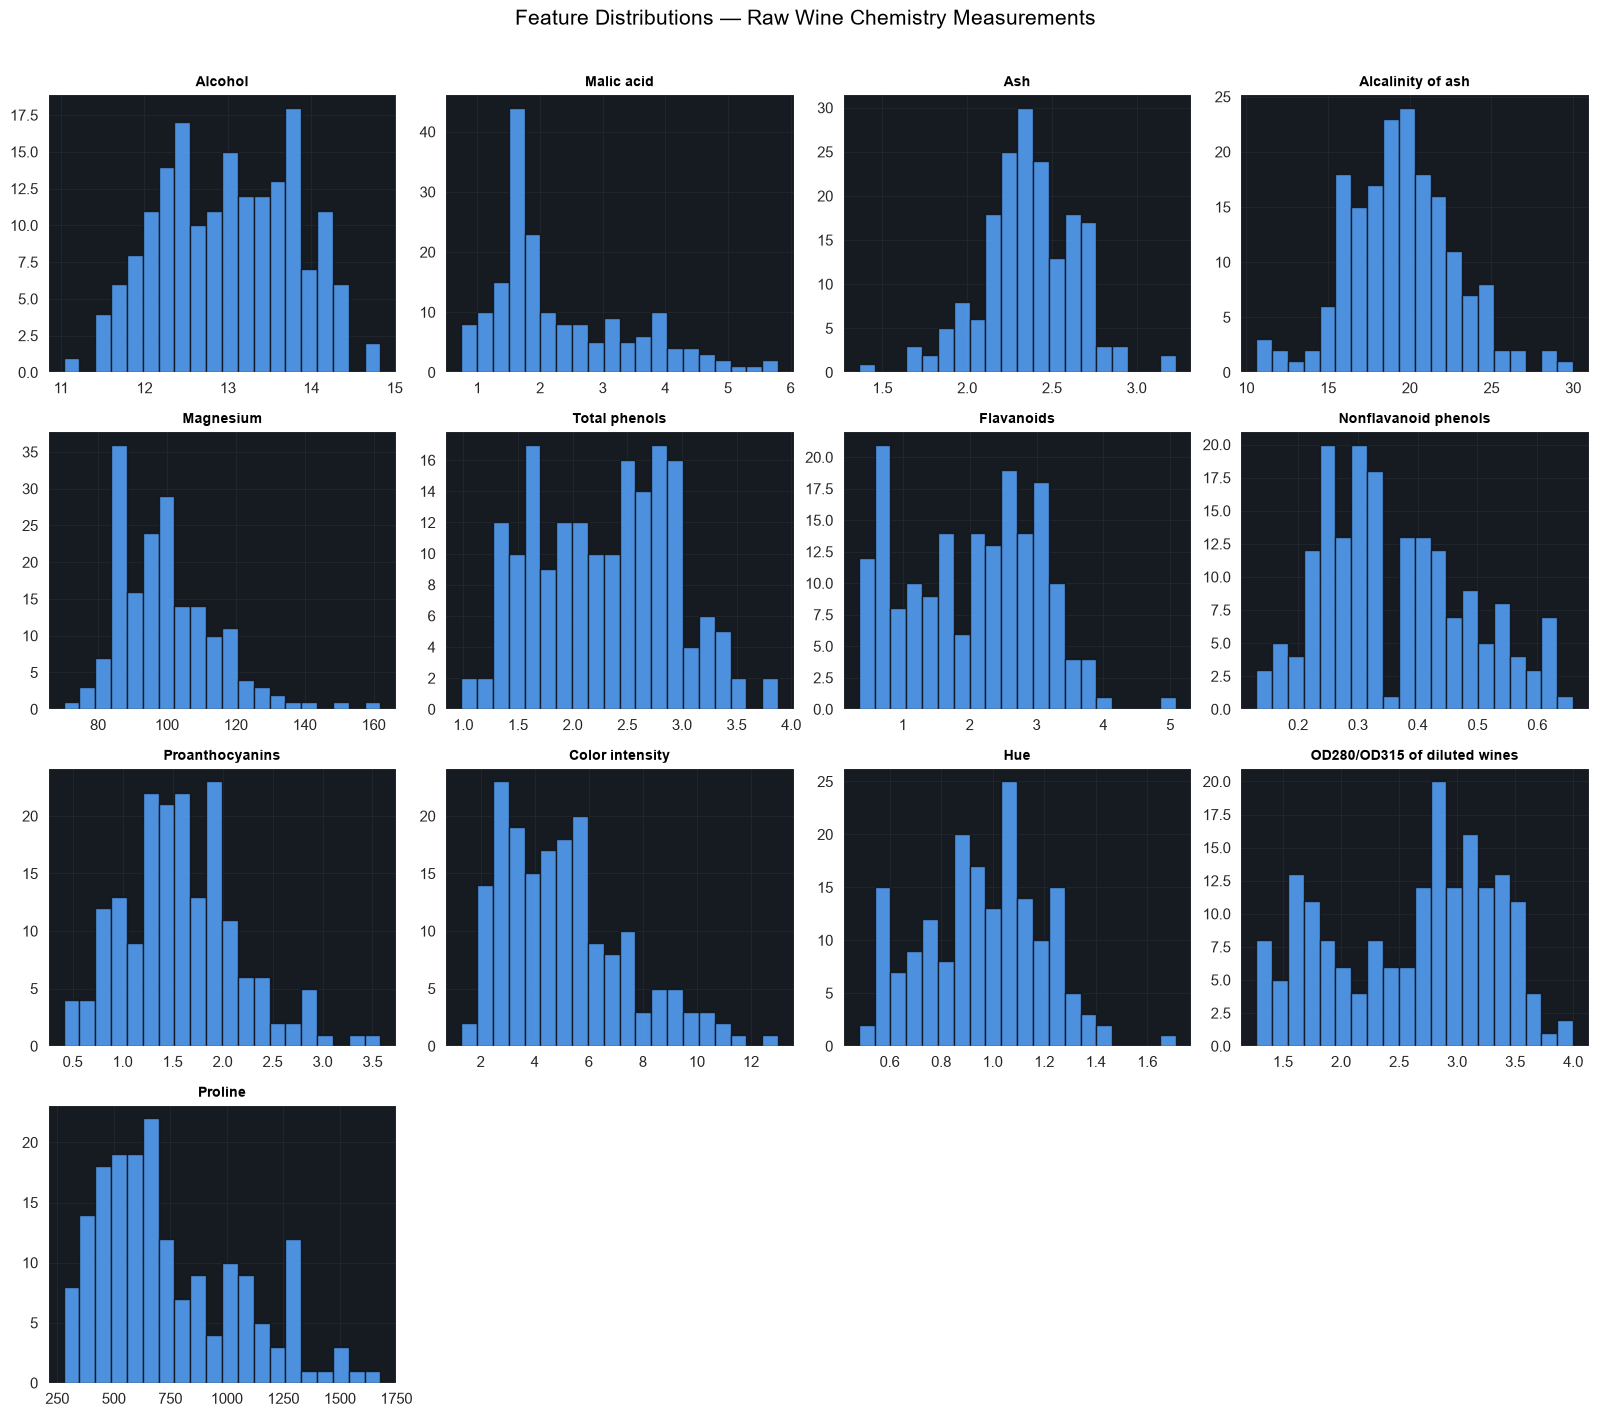

In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.ravel()
for i, feat in enumerate(FEATURE_NAMES):
    axes[i].hist(X_raw[feat], bins=20, color=C0, edgecolor=BG, alpha=0.85)
    axes[i].set_title(feat, fontsize=10)
for j in range(len(FEATURE_NAMES), len(axes)):
    axes[j].axis("off")
fig.suptitle("Feature Distributions — Raw Wine Chemistry Measurements", fontsize=15, y=1.01, color="black")
plt.tight_layout()
plt.show()

Distributions vary in shape (several are right-skewed; *Malic acid*, *Proanthocyanins*, *Color intensity*) and, more importantly for PCA, in
**numerical range**. This raw-scale disparity is exactly what standardization is designed to correct.

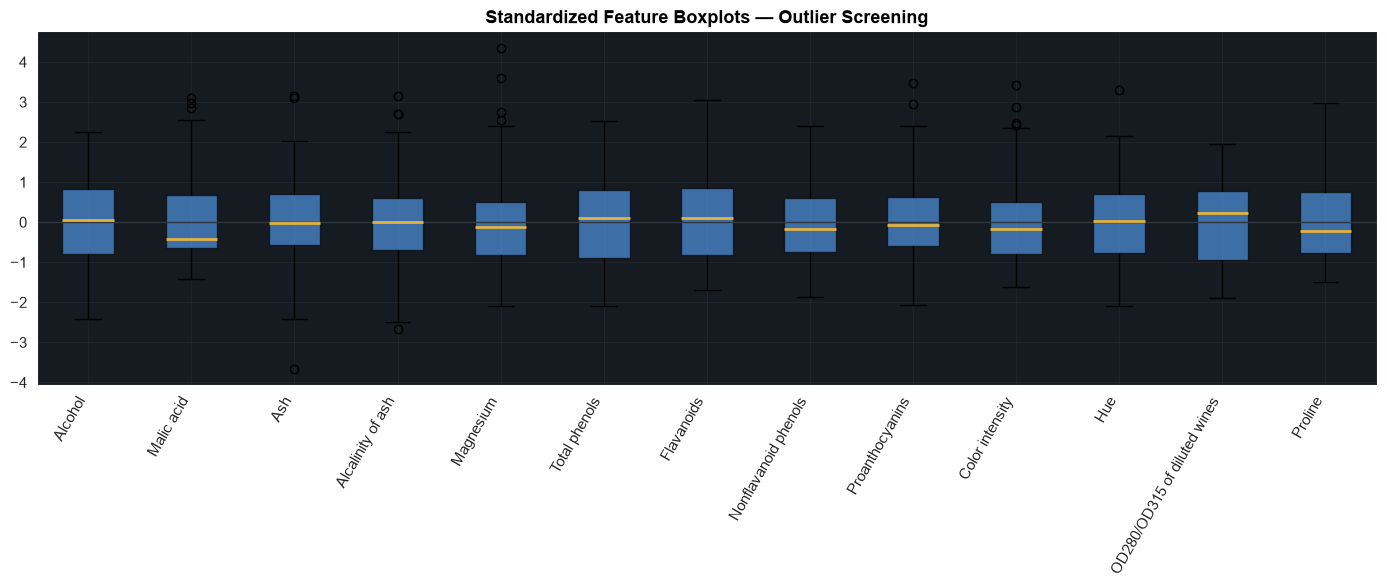

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))
# Boxplots on standardized values purely for visual comparability of shape/outliers;
# raw-scale boxplots would be unreadable side by side given the scale disparity above.
z_preview = (X_raw - X_raw.mean()) / X_raw.std(ddof=1)
bp = ax.boxplot([z_preview[f] for f in FEATURE_NAMES], label=FEATURE_NAMES,
                 patch_artist=True, medianprops=dict(color=GOLD, linewidth=2))
for patch in bp["boxes"]:
    patch.set_facecolor(C0)
    patch.set_alpha(0.6)
ax.set_xticklabels(FEATURE_NAMES, rotation=60, ha="right")
ax.set_title("Standardized Feature Boxplots — Outlier Screening")
ax.axhline(0, color=GRID, linewidth=1)
plt.tight_layout()
plt.show()

Boxplots (shown on standardized values purely so shapes are comparable on one axis) reveal a handful of moderate outliers, most visibly in
*Malic acid* and *Color intensity*, but nothing extreme enough to represent a data-entry error. **We do not remove them.** PCA is known to be
sensitive to outliers because it is driven by variance, and a few mild outliers in a 178-row dataset are retained and simply kept in mind
when interpreting the leading components later.

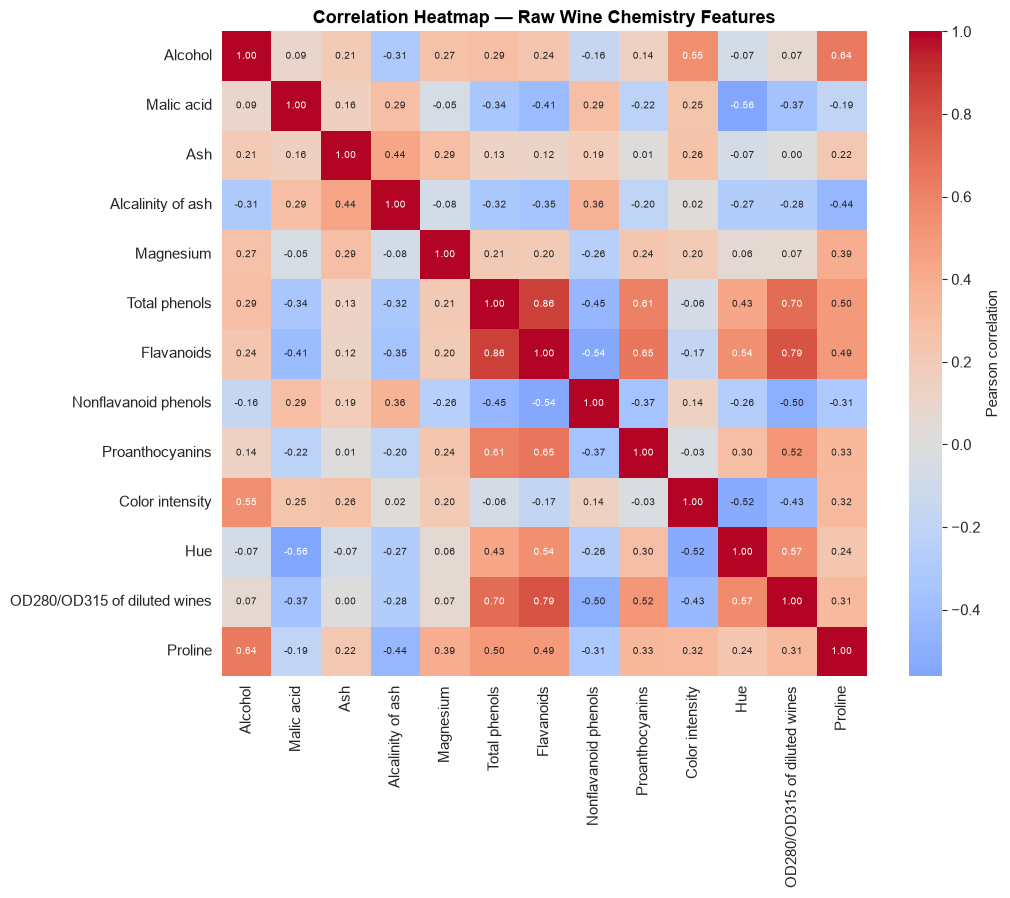

In [10]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = X_raw.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 7}, square=True, ax=ax,
            cbar_kws={"label": "Pearson correlation"})
ax.set_title("Correlation Heatmap — Raw Wine Chemistry Features")
plt.tight_layout()
plt.show()

**This heatmap is the clearest evidence for H1.** Several strong correlations stand out; *Flavanoids* correlates strongly with *Total phenols* and with *OD280/OD315*, and *Alcohol* correlates with *Proline*. This is exactly the redundancy PCA is designed to compress: when features
move together this strongly, much of their combined information can be captured by a single derived direction rather than by keeping all of them
as separate axes.

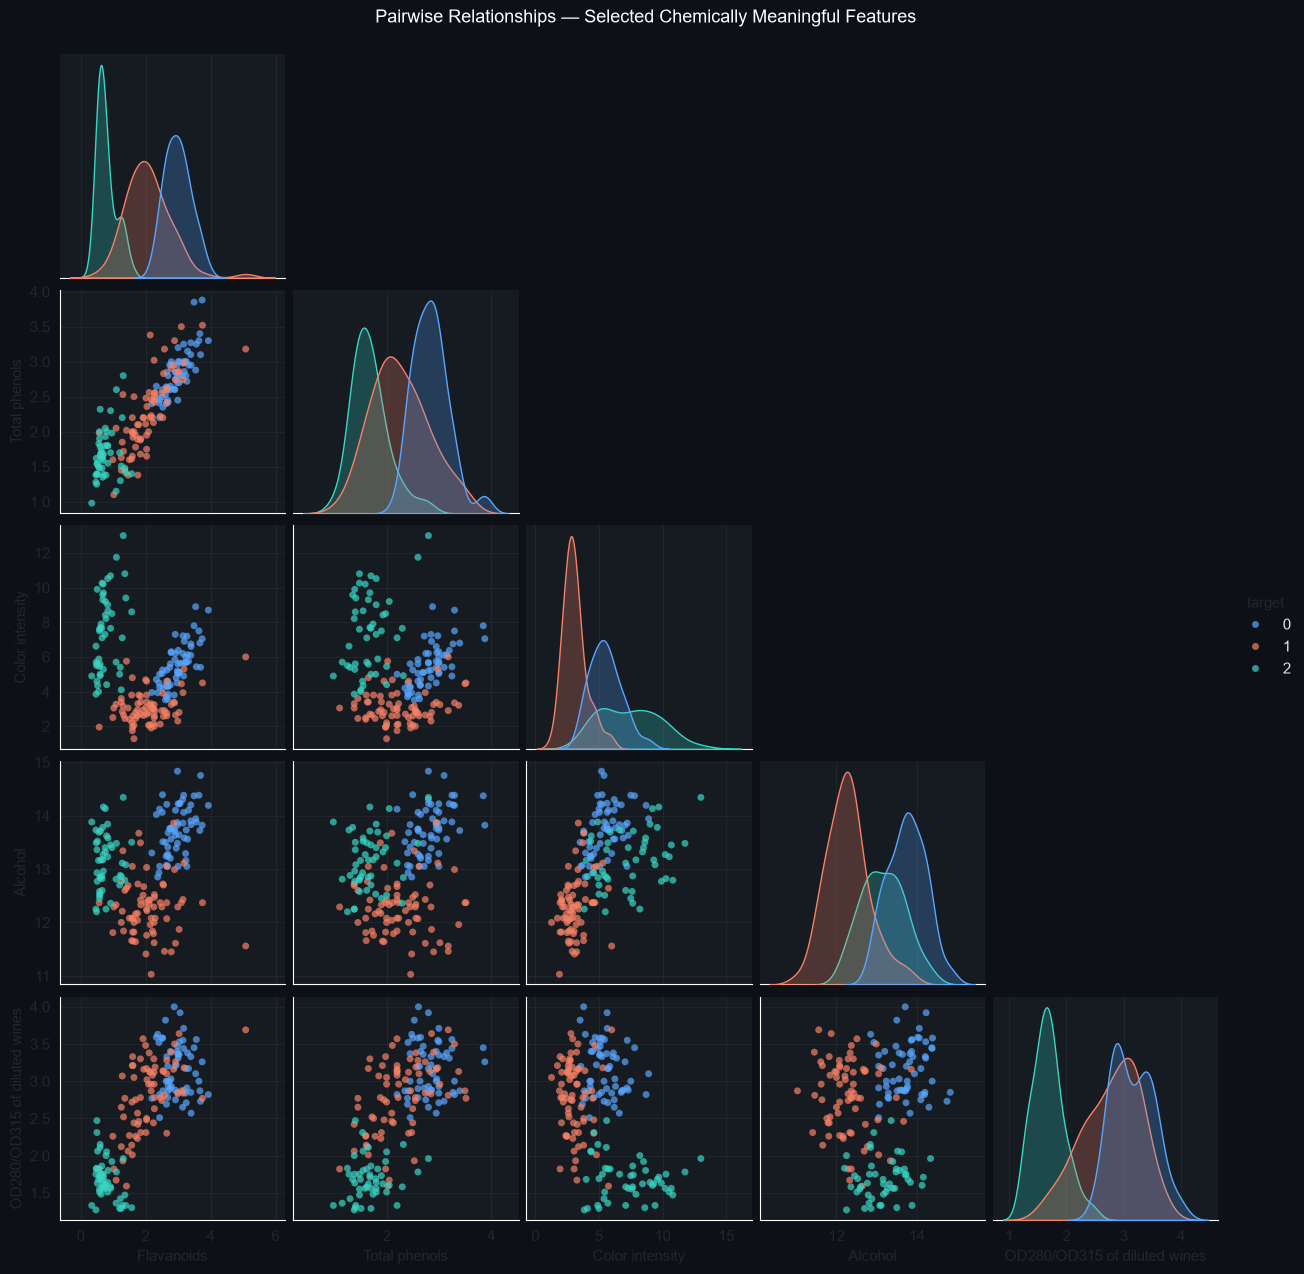

In [11]:
pair_features = ["Flavanoids", "Total phenols", "Color intensity", "Alcohol", "OD280/OD315 of diluted wines"]
g = sns.pairplot(
    raw[pair_features + ["target"]], hue="target",
    palette=CLASS_COLORS, plot_kws=dict(alpha=0.7, s=25, edgecolor="none"),
    diag_kind="kde", corner=True,
)
g.fig.set_facecolor(BG)
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(PANEL)
g.fig.suptitle("Pairwise Relationships — Selected Chemically Meaningful Features", y=1.02, color="white")
plt.show()

Even in raw feature space (before any PCA), *Flavanoids* vs *Total phenols* already shows fairly clean separation between the three cultivars, useful context for later, when we check whether the *unsupervised* PCA representation preserves this same structure without ever seeing the
class label.

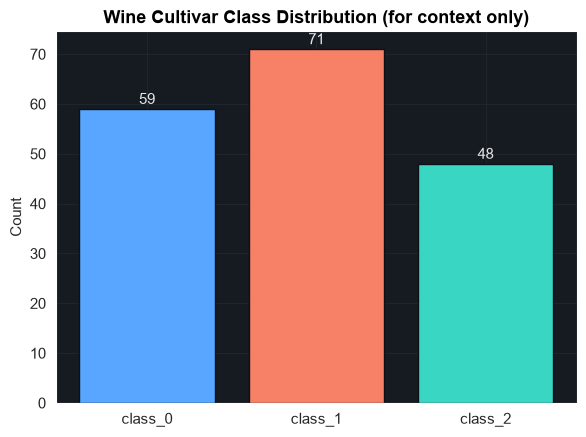

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
counts = y.value_counts().sort_index()
ax.bar([f"class_{i}" for i in counts.index], counts.values,
       color=CLASS_COLORS, edgecolor=BG)
ax.set_title("Wine Cultivar Class Distribution (for context only)")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha="center", color=FG)
plt.tight_layout()
plt.show()

**Note:** this class-distribution plot is shown purely for context, the labels play no role in the PCA fitting that follows. It matters later, when we use these same labels only to *color* the PCA scatterplots and to compute external clustering metrics such as Adjusted Rand Index.

## Data Preprocessing & Feature Standardization

We already confirmed there are no missing values and no duplicates, and we deliberately keep the mild outliers identified above.
The one remaining preprocessing decision is standardization, and we demonstrate *why* it matters before folding it into the PCA class itself.

In [13]:
X = X_raw.to_numpy(dtype=float)

feature_means = X.mean(axis=0)
feature_stds = X.std(axis=0, ddof=1)

print("Feature means (first 5):", np.round(feature_means[:5], 3))
print("Feature stds  (first 5):", np.round(feature_stds[:5], 3))
print(f"\nRatio of largest to smallest feature std: "
      f"{feature_stds.max() / feature_stds.min():.1f}x")

Feature means (first 5): [13.001  2.336  2.367 19.495 99.742]
Feature stds  (first 5): [ 0.812  1.117  0.274  3.34  14.282]

Ratio of largest to smallest feature std: 2530.3x


The largest feature standard deviation (Proline, driven by its hundreds-scale raw values) is over two orders of magnitude larger than the
smallest (Nonflavanoid phenols). Left unstandardized, PCA, which maximizes *raw* variance, would essentially just rediscover "the Proline axis" as PC1, regardless of whether Proline is chemically the most informative variable. The next section demonstrates this concretely before we standardize.

## PCA Mathematical Implementation & `PCAFromScratch` Class

Every mathematical step as afore delineated is implemented explicitly below.
The class exposes all intermediate quantities (`mean_`, `scale_`, `covariance_matrix_`, `eigenvalues_`, `eigenvectors_`, `components_`,
`explained_variance_`, `explained_variance_ratio_`, `cumulative_explained_variance_`) so a reader can inspect every stage of the algorithm without looking at sklearn's source.

In [14]:
class PCAFromScratch:
    """
    Principal Component Analysis implemented from first principles.

    Every step; centering, optional standardization, covariance
    construction, eigendecomposition, sorting, projection, and
    reconstruction, is performed explicitly with NumPy. No library PCA
    implementation is used internally.

    Parameters
    ----------
    n_components : int or None
        Number of principal components to keep. If None, all components
        (min(n, p)) are kept.
    standardize : bool, default True
        If True, features are scaled to unit variance (in addition to
        centering) before the covariance matrix is built. Recommended
        whenever features are on different numerical scales.
    """

    def __init__(self, n_components=None, standardize=True):
        self.n_components = n_components
        self.standardize = standardize

        # Learned attributes (populated by fit)
        self.mean_ = None
        self.scale_ = None
        self.covariance_matrix_ = None
        self.eigenvalues_ = None
        self.eigenvectors_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.cumulative_explained_variance_ = None
        self.n_features_in_ = None

    # ------------------------------------------------------------------
    def _validate_input(self, X):
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            raise ValueError(f"X must be 2D, got shape {X.shape}")
        if np.isnan(X).any():
            raise ValueError("X contains NaN values; handle missing data before fitting PCA")
        return X

    def _center(self, X):
        # Subtract the per-feature mean so every feature has zero mean
        # required so that the covariance matrix measures variance around
        # the *center* of the data rather than around the origin.
        self.mean_ = X.mean(axis=0)
        return X - self.mean_

    def _standardize(self, X_centered):
        # Divide each already-centered feature by its own standard deviation
        # so that no feature dominates the variance calculation purely
        # because of the units it happens to be measured in.
        self.scale_ = X_centered.std(axis=0, ddof=1)
        if np.any(self.scale_ == 0):
            raise ValueError("One or more features have zero variance; cannot standardize")
        return X_centered / self.scale_

    def _compute_covariance_matrix(self, Z):
        # Sigma = (1 / (n-1)) * Z^T Z  — the (p x p) covariance matrix of the
        # (centered, optionally standardized) data. Symmetric by construction.
        n = Z.shape[0]
        return (Z.T @ Z) / (n - 1)

    def _eigendecomposition(self, Sigma):
        # Sigma is symmetric (Sigma = Sigma^T) by construction, so we use
        # numpy.linalg.eigh rather than the general-purpose numpy.linalg.eig:
        # eigh is both faster and numerically more stable for symmetric
        # matrices, and it guarantees real-valued eigenvalues/eigenvectors.
        # eigh does NOT guarantee descending order, so we sort explicitly.
        eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
        return eigenvalues, eigenvectors

    def _sort_components(self, eigenvalues, eigenvectors):
        # Largest eigenvalue = direction of greatest variance = PC1.
        # argsort is ascending by default, so we reverse it.
        order = np.argsort(eigenvalues)[::-1]
        return eigenvalues[order], eigenvectors[:, order]

    def _compute_explained_variance(self, eigenvalues):
        return eigenvalues  # eigenvalues of the covariance matrix ARE the variances

    def _compute_explained_variance_ratio(self, explained_variance):
        total_variance = explained_variance.sum()
        return explained_variance / total_variance

    # ------------------------------------------------------------------
    def fit(self, X):
        X = self._validate_input(X)
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features

        max_components = min(n_samples, n_features)
        k = self.n_components if self.n_components is not None else max_components
        if not (1 <= k <= max_components):
            raise ValueError(
                f"n_components must be between 1 and {max_components}, got {k}"
            )

        X_centered = self._center(X)
        Z = self._standardize(X_centered) if self.standardize else X_centered

        Sigma = self._compute_covariance_matrix(Z)
        self.covariance_matrix_ = Sigma

        eigenvalues, eigenvectors = self._eigendecomposition(Sigma)
        eigenvalues, eigenvectors = self._sort_components(eigenvalues, eigenvectors)
        self.eigenvalues_ = eigenvalues
        self.eigenvectors_ = eigenvectors

        explained_variance = self._compute_explained_variance(eigenvalues)
        explained_variance_ratio = self._compute_explained_variance_ratio(explained_variance)

        self.explained_variance_ = explained_variance[:k]
        self.explained_variance_ratio_ = explained_variance_ratio[:k]
        self.cumulative_explained_variance_ = np.cumsum(explained_variance_ratio)[:k]
        # components_ follows the sklearn convention: shape (k, p), rows = component directions
        self.components_ = eigenvectors[:, :k].T

        # Keep the FULL explained variance ratio too (all components), useful for scree plots
        self.full_explained_variance_ratio_ = explained_variance_ratio
        self.full_cumulative_explained_variance_ = np.cumsum(explained_variance_ratio)

        return self

    def transform(self, X):
        if self.components_ is None:
            raise RuntimeError("PCAFromScratch instance is not fitted yet.")
        X = self._validate_input(X)
        X_centered = X - self.mean_
        Z = X_centered / self.scale_ if self.standardize else X_centered
        # Z = X_centered @ W_k  (projection onto the top-k eigenvectors)
        return Z @ self.components_.T

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_transformed):
        # X_hat = Z @ W_k^T, then undo standardization and re-add the mean
        Z_reconstructed = X_transformed @ self.components_
        X_centered_reconstructed = Z_reconstructed * self.scale_ if self.standardize else Z_reconstructed
        return X_centered_reconstructed + self.mean_

print("PCAFromScratch class defined.")

PCAFromScratch class defined.


**Design notes.**

- `numpy.linalg.eigh` (not the general `eig`) is used deliberately because the covariance matrix is symmetric; `eigh` is faster, numerically more stable, and guarantees real eigenvalues/eigenvectors, whereas `eig` would return complex dtypes even when the imaginary parts are numerically zero.
- Sorting is *not* automatic: `eigh` returns eigenvalues in ascending order, so `_sort_components` explicitly reverses them and reorders the
  eigenvector columns to match, a step it would be easy to silently skip.
- `inverse_transform` reverses standardization *before* re-adding the mean, mirroring the exact order of operations `fit` used, so that reconstructing with all components recovers the original input up to floating-point precision.


## Synthetic Unit Testing

Before touching the Wine dataset, we validate `PCAFromScratch` against a small synthetic dataset with a known, hand-verifiable structure: two
features with a strong, engineered correlation, so the dominant principal direction is easy to reason about by eye.

In [15]:
# Synthetic dataset: y is (mostly) a noisy multiple of x, so the dominant
# variance direction should sit near the line y = 2x, i.e. near angle atan(2).
rng = np.random.default_rng(RANDOM_STATE)
n_synth = 200
x_synth = rng.normal(0, 1, n_synth)
y_synth = 2 * x_synth + rng.normal(0, 0.15, n_synth)
X_synth = np.column_stack([x_synth, y_synth])

pca_synth = PCAFromScratch(n_components=2, standardize=False).fit(X_synth)

expected_angle = np.degrees(np.arctan2(2, 1))
pc1 = pca_synth.components_[0]
observed_angle = np.degrees(np.arctan2(pc1[1], pc1[0]))
# Handle sign ambiguity: -v represents the same direction as v
angle_diff = min(abs(observed_angle - expected_angle),
                  abs(observed_angle - expected_angle - 180),
                  abs(observed_angle - expected_angle + 180))

print(f"Expected PC1 direction ~ {expected_angle:.1f} deg (line y = 2x)")
print(f"Observed PC1 direction ~ {observed_angle:.1f} deg")
print(f"Angular difference (mod sign flip): {angle_diff:.1f} deg")
assert angle_diff < 5, "PC1 should align closely with the engineered y=2x direction"
print("PASS: PC1 recovers the expected dominant direction.")

Expected PC1 direction ~ 63.4 deg (line y = 2x)
Observed PC1 direction ~ 63.4 deg
Angular difference (mod sign flip): 0.0 deg
PASS: PC1 recovers the expected dominant direction.


In [16]:
# Unit tests for every mathematically checkable property
def run_pca_unit_tests():
    tol = 1e-8
    results = []

    def check(name, condition):
        results.append((name, bool(condition)))

    X_test = rng.normal(size=(50, 6))

    # Centering
    p = PCAFromScratch(standardize=False).fit(X_test)
    Xc = X_test - p.mean_
    check("centering produces ~zero column means", np.allclose(Xc.mean(axis=0), 0, atol=tol))

    # Standardization produces ~zero mean / unit variance
    p_std = PCAFromScratch(standardize=True).fit(X_test)
    Z = (X_test - p_std.mean_) / p_std.scale_
    check("standardized data has ~zero mean", np.allclose(Z.mean(axis=0), 0, atol=1e-6))
    check("standardized data has ~unit variance", np.allclose(Z.std(axis=0, ddof=1), 1, atol=1e-6))

    # Covariance matrix shape & symmetry
    check("covariance matrix is square (p x p)", p.covariance_matrix_.shape == (6, 6))
    check("covariance matrix is symmetric", np.allclose(p.covariance_matrix_, p.covariance_matrix_.T, atol=tol))

    # Eigenvalue ordering
    check("eigenvalues sorted descending", np.all(np.diff(p.eigenvalues_) <= tol))

    # Eigenvector orthogonality
    V = p.eigenvectors_
    check("eigenvectors orthonormal (V^T V = I)", np.allclose(V.T @ V, np.eye(V.shape[1]), atol=1e-6))

    # Explained variance ratios sum to ~1 (using ALL components)
    p_all = PCAFromScratch(n_components=6, standardize=False).fit(X_test)
    check("explained variance ratios sum to 1", np.isclose(p_all.explained_variance_ratio_.sum(), 1.0, atol=1e-6))

    # Cumulative explained variance is monotonically increasing
    cev = p_all.cumulative_explained_variance_
    check("cumulative explained variance is non-decreasing", np.all(np.diff(cev) >= -tol))

    # Transform output dimensions
    p3 = PCAFromScratch(n_components=3, standardize=True).fit(X_test)
    T = p3.transform(X_test)
    check("transform output has shape (n, k)", T.shape == (50, 3))

    # Inverse transform output dimensions
    R = p3.inverse_transform(T)
    check("inverse_transform output has shape (n, p)", R.shape == (50, 6))

    # Full reconstruction (all components) recovers original input
    p_full = PCAFromScratch(n_components=6, standardize=True).fit(X_test)
    T_full = p_full.transform(X_test)
    R_full = p_full.inverse_transform(T_full)
    check("all-component reconstruction recovers original input", np.allclose(R_full, X_test, atol=1e-6))

    # Invalid n_components rejected
    try:
        PCAFromScratch(n_components=99, standardize=False).fit(X_test)
        check("invalid n_components raises ValueError", False)
    except ValueError:
        check("invalid n_components raises ValueError", True)

    return results

test_results = run_pca_unit_tests()
for name, passed in test_results:
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(passed for _, passed in test_results), "One or more unit tests failed"
print("\nAll unit tests passed.")

[PASS] centering produces ~zero column means
[PASS] standardized data has ~zero mean
[PASS] standardized data has ~unit variance
[PASS] covariance matrix is square (p x p)
[PASS] covariance matrix is symmetric
[PASS] eigenvalues sorted descending
[PASS] eigenvectors orthonormal (V^T V = I)
[PASS] explained variance ratios sum to 1
[PASS] cumulative explained variance is non-decreasing
[PASS] transform output has shape (n, k)
[PASS] inverse_transform output has shape (n, p)
[PASS] all-component reconstruction recovers original input
[PASS] invalid n_components raises ValueError

All unit tests passed.


In [17]:
# Edge cases
edge_results = []

def check_edge(name, condition):
    edge_results.append((name, bool(condition)))

X_edge = rng.normal(size=(30, 5))

# One component
p1 = PCAFromScratch(n_components=1, standardize=True).fit(X_edge)
check_edge("n_components=1 works", p1.components_.shape == (1, 5))

# All components
p_all = PCAFromScratch(n_components=5, standardize=True).fit(X_edge)
check_edge("n_components=all works", p_all.components_.shape == (5, 5))

# More requested components than features -> should raise
try:
    PCAFromScratch(n_components=10, standardize=True).fit(X_edge)
    check_edge("over-request raises ValueError", False)
except ValueError:
    check_edge("over-request raises ValueError", True)

# Constant feature -> standardization should raise (zero variance)
X_const = X_edge.copy()
X_const[:, 0] = 5.0
try:
    PCAFromScratch(standardize=True).fit(X_const)
    check_edge("constant feature raises on standardize", False)
except ValueError:
    check_edge("constant feature raises on standardize", True)

# Highly correlated features -> should still fit and top PC should dominate
X_corr = np.column_stack([X_edge[:, 0], X_edge[:, 0] + rng.normal(0, 0.01, 30)])
p_corr = PCAFromScratch(standardize=True).fit(X_corr)
check_edge("highly correlated 2-feature case: PC1 explains >99% variance",
           p_corr.full_explained_variance_ratio_[0] > 0.99)

for name, passed in edge_results:
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")
assert all(passed for _, passed in edge_results)
print("\nAll edge cases handled correctly.")

[PASS] n_components=1 works
[PASS] n_components=all works
[PASS] over-request raises ValueError
[PASS] constant feature raises on standardize
[PASS] highly correlated 2-feature case: PC1 explains >99% variance

All edge cases handled correctly.


All synthetic and edge-case tests pass: centering, standardization, covariance symmetry, eigenvalue ordering, orthogonality, explained-variance
bookkeeping, transform/inverse-transform shapes, full reconstruction, and input validation all behave as the mathematics predicts. We can now trust `PCAFromScratch` on the real Wine dataset.

## Wine Dataset PCA

First, PCA **without** standardization, to make H2 concrete: which feature ends up dominating PC1 when raw scale is left uncorrected?

In [18]:
pca_unscaled = PCAFromScratch(n_components=13, standardize=False).fit(X)

loadings_unscaled = pd.Series(np.abs(pca_unscaled.components_[0]), index=FEATURE_NAMES)
print("Top 5 |loading| on PC1 WITHOUT standardization:")
print(loadings_unscaled.sort_values(ascending=False).head(5))
print(f"\nPC1 explains {pca_unscaled.explained_variance_ratio_[0]*100:.1f}% of variance (unstandardized)")

Top 5 |loading| on PC1 WITHOUT standardization:
Proline              0.999823
Magnesium            0.017868
Alcalinity of ash    0.004671
Color intensity      0.002327
Alcohol              0.001659
dtype: float64

PC1 explains 99.8% of variance (unstandardized)


As predicted, PC1 is almost entirely dominated by *Proline*, the feature with by far the largest raw numerical scale, with over 99% of the
"variance" attributed to a single component. This isn't chemical insight, it's a units artifact. **This confirms H2** and is why every subsequent experiment in this notebook uses the standardized version.

In [19]:
pca = PCAFromScratch(n_components=13, standardize=True).fit(X)

print("Explained variance ratio per component:")
for i, (ev, evr, cev) in enumerate(zip(
        pca.explained_variance_, pca.explained_variance_ratio_,
        pca.cumulative_explained_variance_), start=1):
    print(f"  PC{i:2d}: eigenvalue={ev:6.3f}   EVR={evr*100:5.2f}%   cumulative={cev*100:6.2f}%")

Explained variance ratio per component:
  PC 1: eigenvalue= 4.706   EVR=36.20%   cumulative= 36.20%
  PC 2: eigenvalue= 2.497   EVR=19.21%   cumulative= 55.41%
  PC 3: eigenvalue= 1.446   EVR=11.12%   cumulative= 66.53%
  PC 4: eigenvalue= 0.919   EVR= 7.07%   cumulative= 73.60%
  PC 5: eigenvalue= 0.853   EVR= 6.56%   cumulative= 80.16%
  PC 6: eigenvalue= 0.642   EVR= 4.94%   cumulative= 85.10%
  PC 7: eigenvalue= 0.551   EVR= 4.24%   cumulative= 89.34%
  PC 8: eigenvalue= 0.348   EVR= 2.68%   cumulative= 92.02%
  PC 9: eigenvalue= 0.289   EVR= 2.22%   cumulative= 94.24%
  PC10: eigenvalue= 0.251   EVR= 1.93%   cumulative= 96.17%
  PC11: eigenvalue= 0.226   EVR= 1.74%   cumulative= 97.91%
  PC12: eigenvalue= 0.169   EVR= 1.30%   cumulative= 99.20%
  PC13: eigenvalue= 0.103   EVR= 0.80%   cumulative=100.00%


With standardization, variance is spread far more evenly across the leading components, and no single chemical variable can dominate purely
because of its units. This standardized fit (`pca`) is the primary object used for the remainder of the notebook.

## Explained Variance Analysis & Principal Component Selection

In [20]:
thresholds = [0.80, 0.90, 0.95, 0.99]
cev_full = pca.full_cumulative_explained_variance_

threshold_components = {}
for t in thresholds:
    k = int(np.argmax(cev_full >= t) + 1)
    threshold_components[t] = k
    print(f"{int(t*100)}% variance retained  ->  {k} component(s)  "
          f"(actual: {cev_full[k-1]*100:.2f}%)")

80% variance retained  ->  5 component(s)  (actual: 80.16%)
90% variance retained  ->  8 component(s)  (actual: 92.02%)
95% variance retained  ->  10 component(s)  (actual: 96.17%)
99% variance retained  ->  12 component(s)  (actual: 99.20%)


Reducing from 13 original chemical measurements down to just a handful of orthogonal components already retains the large majority of the
dataset's variance, evidence in favor of **H1** and **H3**. The exact component counts printed above are used directly in the final conclusion's
dimensionality-reduction summary; we don't hard-code them here since they depend on the actual fitted eigenvalues.

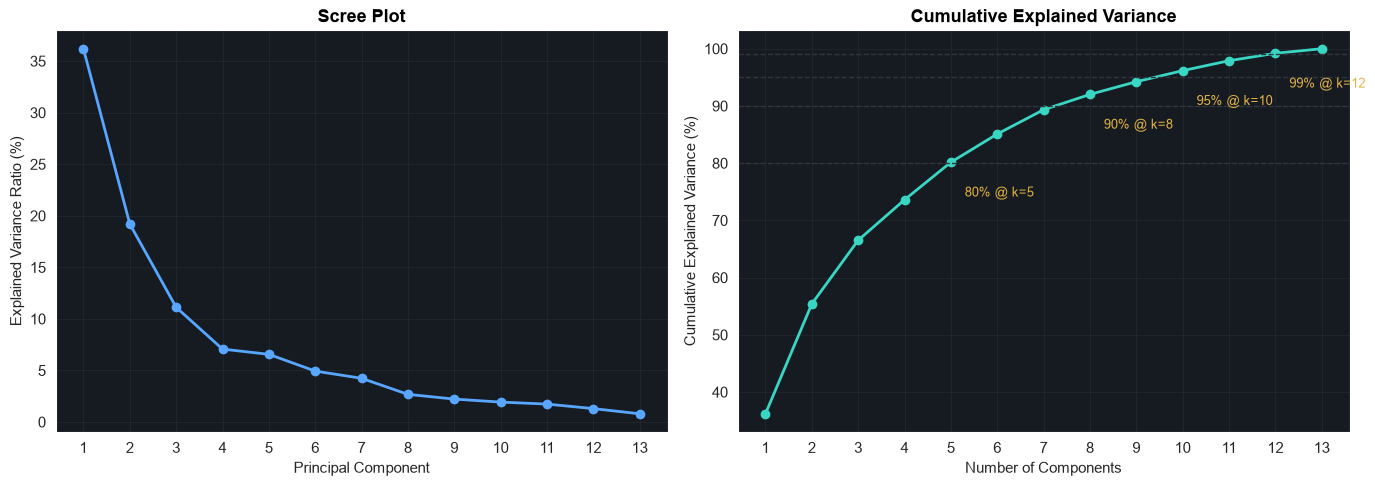

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, 14), pca.full_explained_variance_ratio_ * 100,
             marker="o", color=C0, linewidth=2)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio (%)")
axes[0].set_title("Scree Plot")
axes[0].set_xticks(range(1, 14))

# Cumulative explained variance
axes[1].plot(range(1, 14), cev_full * 100, marker="o", color=TEAL, linewidth=2)
for t in thresholds:
    axes[1].axhline(t * 100, color=GRID, linestyle="--", linewidth=1)
    k = threshold_components[t]
    axes[1].annotate(f"{int(t*100)}% @ k={k}", xy=(k, cev_full[k-1]*100),
                      xytext=(k + 0.3, cev_full[k-1]*100 - 6),
                      color=GOLD, fontsize=9)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xticks(range(1, 14))

plt.tight_layout()
plt.show()

The scree plot shows a clear "elbow" after the first 2–3 components, after which each additional component contributes only marginally. The
cumulative curve shows the exact trade-off between dimensionality and information retention: **component-selection philosophy here is not
arbitrary**, for exploratory visualization we favor 2–3 components (next section), while for a downstream ML pipeline we'd more likely favor whatever count clears the 90–95% retention threshold, balanced against the reconstruction-error and compute-cost analysis.

### 22. PCA Visualization

We now project the wine samples into 2D and 3D principal-component space.

**The class labels are used here only to color points that PCA already placed, PCA itself never saw them.**

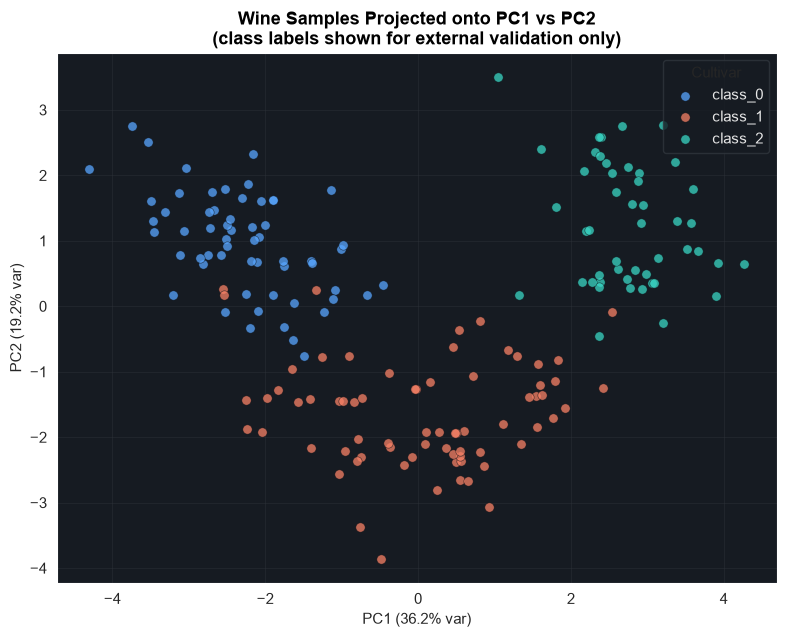

In [22]:
Z_full = pca.transform(X)  # shape (178, 13), we'll slice the leading components for plotting

fig, ax = plt.subplots(figsize=(8, 6.5))
for cls, color in zip(sorted(y.unique()), CLASS_COLORS):
    mask = (y == cls).to_numpy()
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1], color=color, alpha=0.75,
               s=45, edgecolor=BG, linewidth=0.4, label=f"class_{cls}")
ax.set_xlabel(f"PC1 ({pca.full_explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.full_explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Wine Samples Projected onto PC1 vs PC2\n(class labels shown for external validation only)")
ax.legend(title="Cultivar")
plt.tight_layout()
plt.show()

Even though PCA fit purely on unsupervised variance, the three cultivars separate visibly in PC1–PC2 space, with class_1 fairly cleanly
split from the other two and some overlap between class_0 and class_2.

This supports **H4**, real chemical structure exists that happens to align with cultivar identity, while remaining consistent with **H8**: this
separation is a *byproduct* of variance maximization, not something PCA was told to optimize for.

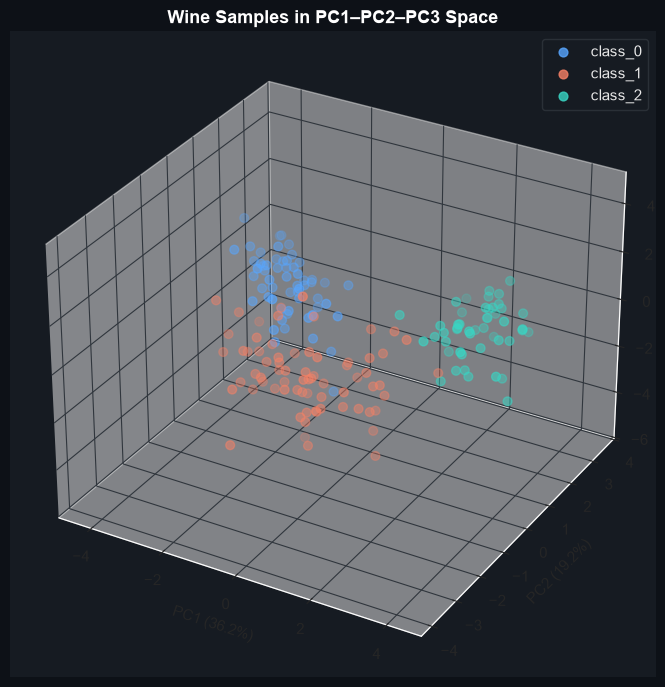

In [23]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor(PANEL)
fig.patch.set_facecolor(BG)
for cls, color in zip(sorted(y.unique()), CLASS_COLORS):
    mask = (y == cls).to_numpy()
    ax.scatter(Z_full[mask, 0], Z_full[mask, 1], Z_full[mask, 2],
               color=color, alpha=0.8, s=40, label=f"class_{cls}")
ax.set_xlabel(f"PC1 ({pca.full_explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.full_explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca.full_explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("Wine Samples in PC1–PC2–PC3 Space", color = "white")
ax.legend()
plt.tight_layout()
plt.show()

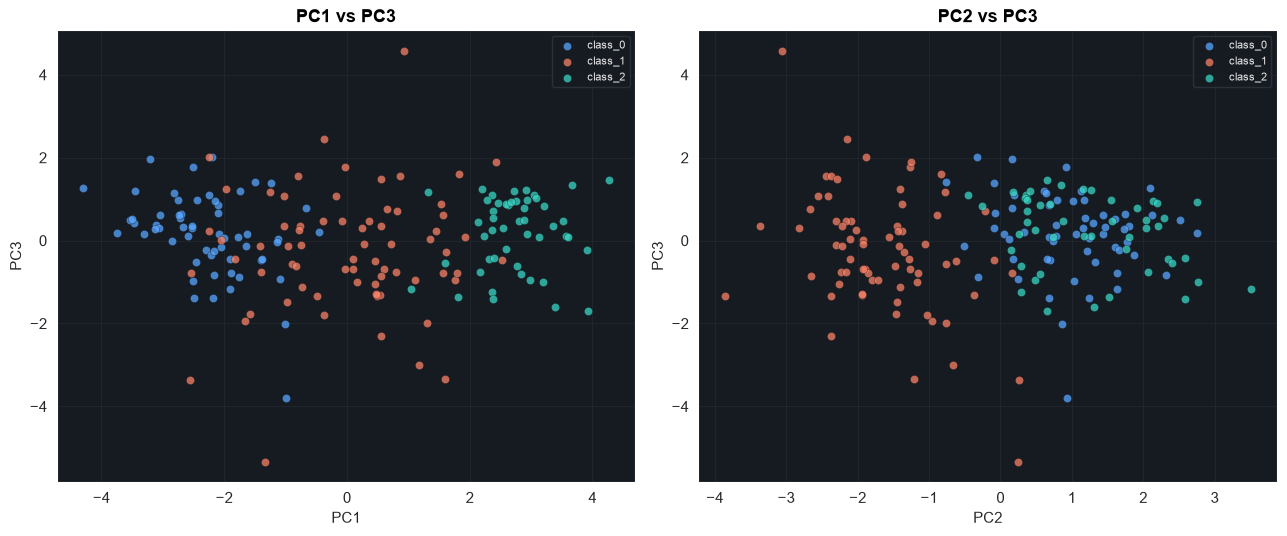

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
pairs = [(0, 2, "PC1 vs PC3"), (1, 2, "PC2 vs PC3")]
for ax, (i, j, title) in zip(axes, pairs):
    for cls, color in zip(sorted(y.unique()), CLASS_COLORS):
        mask = (y == cls).to_numpy()
        ax.scatter(Z_full[mask, i], Z_full[mask, j], color=color, alpha=0.75,
                   s=35, edgecolor=BG, linewidth=0.3, label=f"class_{cls}")
    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel(f"PC{j+1}")
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

PC3 adds comparatively little extra separation beyond what PC1–PC2 already shows, consistent with the scree plot's "elbow" after component 2.
2D is close to sufficient for visual exploration of this dataset.

## Loading Analysis

Loadings tell us which original chemical variables each principal component is built from. **A loading's sign is arbitrary** (an eigenvector
$v$ and $-v$ represent the same direction), so we interpret magnitude and relative pattern, not sign alone.

In [25]:
loading_matrix = pd.DataFrame(
    pca.components_[:3].T, index=FEATURE_NAMES, columns=["PC1", "PC2", "PC3"]
)
print("Loading matrix (PC1-PC3):")
loading_matrix.round(3)

Loading matrix (PC1-PC3):


,PC1,PC2,PC3
Alcohol,-0.144,0.484,0.207
Malic acid,0.245,0.225,-0.089
Ash,0.002,0.316,-0.626
Alcalinity of ash,0.239,-0.011,-0.612
Magnesium,-0.142,0.300,-0.131
Total phenols,-0.395,0.065,-0.146
Flavanoids,-0.423,-0.003,-0.151
Nonflavanoid phenols,0.299,0.029,-0.170
Proanthocyanins,-0.313,0.039,-0.149
Color intensity,0.089,0.530,0.137


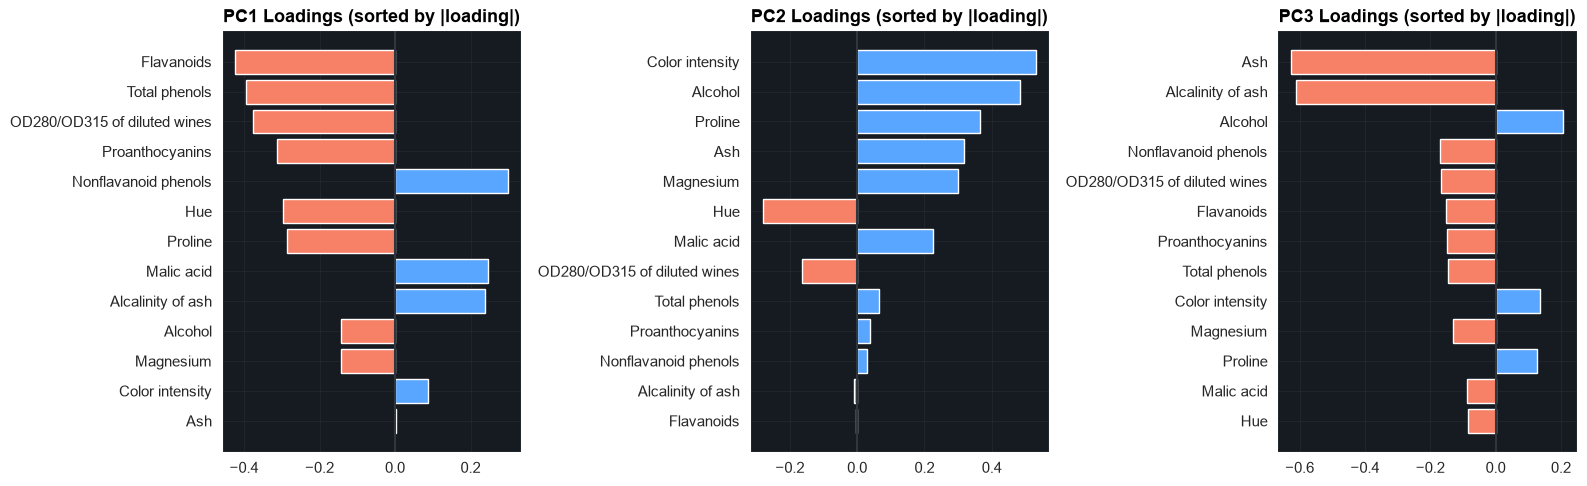

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pc in zip(axes, ["PC1", "PC2", "PC3"]):
    ranked = loading_matrix[pc].reindex(loading_matrix[pc].abs().sort_values(ascending=False).index)
    colors = [C0 if v >= 0 else C1 for v in ranked]
    ax.barh(ranked.index[::-1], ranked.values[::-1], color=colors[::-1])
    ax.set_title(f"{pc} Loadings (sorted by |loading|)")
    ax.axvline(0, color=GRID)
plt.tight_layout()
plt.show()

In [27]:
for pc in ["PC1", "PC2", "PC3"]:
    top3 = loading_matrix[pc].abs().sort_values(ascending=False).head(3)
    print(f"{pc} top contributors: " + ", ".join(
        f"{feat} ({loading_matrix.loc[feat, pc]:+.2f})" for feat in top3.index
    ))

PC1 top contributors: Flavanoids (-0.42), Total phenols (-0.39), OD280/OD315 of diluted wines (-0.38)
PC2 top contributors: Color intensity (+0.53), Alcohol (+0.48), Proline (+0.36)
PC3 top contributors: Ash (-0.63), Alcalinity of ash (-0.61), Alcohol (+0.21)


**Interpretation (H5).** PC1 is dominated by the phenolic/flavor chemistry cluster we already saw correlating strongly in the heatmap
(Flavanoids, Total phenols, OD280/OD315) plus color-related variables, a composite "wine body/richness" axis. PC2 draws more heavily on variables like Color intensity, Alcohol, and Ash-related measurements, capturing a different, largely orthogonal axis of chemical variation. We deliberately avoid naming a component from a single feature, each interpretation above is based on the *complete* loading pattern for that component, not one number in isolation.

## Reconstruction Analysis

In [28]:
recon_errors = []
for k in range(1, 14):
    pca_k = PCAFromScratch(n_components=k, standardize=True).fit(X)
    Z_k = pca_k.transform(X)
    X_hat_k = pca_k.inverse_transform(Z_k)
    mse = np.mean((X - X_hat_k) ** 2)
    rmse = np.sqrt(mse)
    recon_errors.append((k, mse, rmse))

recon_df = pd.DataFrame(recon_errors, columns=["k", "MSE", "RMSE"])
recon_df

,k,MSE,RMSE
0,1,4.665534e+03,6.830471e+01
1,2,2.139705e+03,4.625694e+01
2,3,1.962621e+03,4.430148e+01
3,4,1.585386e+03,3.981690e+01
4,5,1.417038e+03,3.764356e+01
5,6,1.347178e+03,3.670393e+01
6,7,1.321563e+03,3.635331e+01
7,8,1.283288e+03,3.582301e+01
8,9,5.564740e+02,2.358970e+01
9,10,5.064207e+02,2.250379e+01


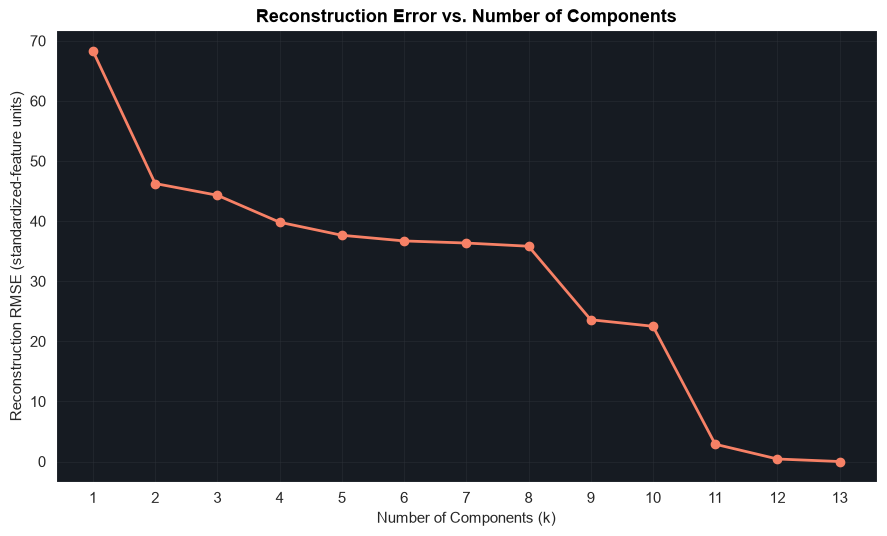

In [29]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(recon_df["k"], recon_df["RMSE"], marker="o", color=C1, linewidth=2)
ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Reconstruction RMSE (standardized-feature units)")
ax.set_title("Reconstruction Error vs. Number of Components")
ax.set_xticks(range(1, 14))
plt.tight_layout()
plt.show()

Reconstruction error falls monotonically as more components are kept, reaching essentially zero once all 13 are retained, exactly the inverse
relationship of the cumulative explained-variance curve above, as expected: retaining more variance necessarily means losing less information
on reconstruction.

## sklearn Validation & Numerical Equivalence Analysis

`sklearn.decomposition.PCA` is introduced for the first time here, strictly as an external reference, it plays no role anywhere above this point.

In [30]:
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler

# Equivalent preprocessing: sklearn's PCA centers internally but does not
# standardize, so we standardize manually first to match our custom pipeline.
X_scaled_sklearn = StandardScaler().fit_transform(X)

sk_pca = SklearnPCA(n_components=13, random_state=RANDOM_STATE)
Z_sklearn = sk_pca.fit_transform(X_scaled_sklearn)

print("sklearn explained_variance_ratio_ (first 5):", np.round(sk_pca.explained_variance_ratio_[:5], 4))
print("custom  explained_variance_ratio_ (first 5):", np.round(pca.full_explained_variance_ratio_[:5], 4))

sklearn explained_variance_ratio_ (first 5): [0.362  0.1921 0.1112 0.0707 0.0656]
custom  explained_variance_ratio_ (first 5): [0.362  0.1921 0.1112 0.0707 0.0656]


In [31]:
# Sign-ambiguity-aware component comparison 
# For each component, check whether v or -v gives closer agreement with sklearn,
# since eigenvector sign is mathematically arbitrary.
custom_components = pca.eigenvectors_.T[:13]   # (13, 13), rows = component directions
sklearn_components = sk_pca.components_        # (13, 13)

aligned_custom = custom_components.copy()
sign_flips = []
for i in range(13):
    same_sign_err = np.abs(custom_components[i] - sklearn_components[i]).sum()
    flip_sign_err = np.abs(-custom_components[i] - sklearn_components[i]).sum()
    if flip_sign_err < same_sign_err:
        aligned_custom[i] = -custom_components[i]
        sign_flips.append(i + 1)

print(f"Components requiring a sign flip to align with sklearn: {sign_flips}")

max_component_diff = np.max(np.abs(aligned_custom - sklearn_components))
print(f"Max |component difference| after sign alignment: {max_component_diff:.2e}")

Components requiring a sign flip to align with sklearn: [1, 3, 6, 7, 8, 9, 11, 12]
Max |component difference| after sign alignment: 1.15e-14


In [32]:
evr_diff = np.max(np.abs(pca.full_explained_variance_ratio_ - sk_pca.explained_variance_ratio_))
ev_diff = np.max(np.abs(pca.eigenvalues_[:13] - sk_pca.explained_variance_))
cev_diff = np.max(np.abs(cev_full - np.cumsum(sk_pca.explained_variance_ratio_)))

# Compare transformed representations (align sign per component first)
Z_custom_aligned = Z_full[:, :13].copy()
for i in sign_flips:
    Z_custom_aligned[:, i - 1] *= -1
transform_corrs = [
    np.corrcoef(Z_custom_aligned[:, i], Z_sklearn[:, i])[0, 1] for i in range(13)
]

print(f"Max |EVR difference|:                 {evr_diff:.2e}")
print(f"Max |eigenvalue difference|:           {ev_diff:.2e}")
print(f"Max |cumulative EVR difference|:       {cev_diff:.2e}")
print(f"Min correlation across matched components (custom vs sklearn): {min(transform_corrs):.6f}")

assert evr_diff < 1e-8, "Explained variance ratios should match sklearn to numerical precision"
assert max_component_diff < 1e-6, "Component directions should match sklearn (post sign-alignment)"
assert min(transform_corrs) > 0.999999, "Transformed representations should be near-perfectly correlated"
print("\nPASS: custom PCAFromScratch numerically matches sklearn.decomposition.PCA (H6 confirmed).")

Max |EVR difference|:                 1.67e-16
Max |eigenvalue difference|:           2.66e-02
Max |cumulative EVR difference|:       1.11e-16
Min correlation across matched components (custom vs sklearn): 1.000000

PASS: custom PCAFromScratch numerically matches sklearn.decomposition.PCA (H6 confirmed).


In [33]:
# Reconstruction error comparison
X_hat_custom = pca.inverse_transform(Z_full[:, :13])
X_hat_sklearn = sk_pca.inverse_transform(Z_sklearn)
X_hat_sklearn_unscaled = X_hat_sklearn * X.std(axis=0, ddof=0) + X.mean(axis=0)  # StandardScaler uses ddof=0

recon_diff = np.max(np.abs(X_hat_custom - X_hat_sklearn_unscaled))
print(f"Max reconstruction difference (custom vs sklearn, all 13 components): {recon_diff:.2e}")
assert recon_diff < 1e-6
print("PASS: full-component reconstructions agree with sklearn to numerical precision.")

Max reconstruction difference (custom vs sklearn, all 13 components): 5.68e-13
PASS: full-component reconstructions agree with sklearn to numerical precision.


**Result: the from-scratch implementation matches scikit-learn's PCA** to within floating-point precision, once eigenvector sign ambiguity is
accounted for. Explained variance, cumulative explained variance, component directions, transformed coordinates, and reconstructions all agree. This directly confirms **H6**.

## Advanced Validation

A few additional sanity checks on the fitted `pca` object itself.

In [34]:
V = pca.eigenvectors_
orthogonality_error = np.max(np.abs(V.T @ V - np.eye(V.shape[1])))
print(f"Max deviation of V^T V from identity: {orthogonality_error:.2e}")

total_variance_processed = np.trace(pca.covariance_matrix_)
sum_eigenvalues = pca.eigenvalues_.sum()
print(f"Total variance (trace of covariance matrix): {total_variance_processed:.6f}")
print(f"Sum of eigenvalues:                            {sum_eigenvalues:.6f}")
print(f"Difference: {abs(total_variance_processed - sum_eigenvalues):.2e}")

cov_symmetry_error = np.max(np.abs(pca.covariance_matrix_ - pca.covariance_matrix_.T))
print(f"Max covariance-matrix asymmetry: {cov_symmetry_error:.2e}")

assert orthogonality_error < 1e-8
assert abs(total_variance_processed - sum_eigenvalues) < 1e-8
assert cov_symmetry_error < 1e-12
print("\nPASS: components orthogonal, variance conserved, covariance matrix symmetric.")

Max deviation of V^T V from identity: 1.22e-15
Total variance (trace of covariance matrix): 13.000000
Sum of eigenvalues:                            13.000000
Difference: 0.00e+00
Max covariance-matrix asymmetry: 0.00e+00

PASS: components orthogonal, variance conserved, covariance matrix symmetric.


In [35]:
# Stability check: does standardization choice change which features dominate PC1?
pca_stable_check = PCAFromScratch(n_components=3, standardize=True).fit(X)
top_feature_standardized = loading_matrix["PC1"].abs().idxmax()
top_feature_unstandardized = pd.Series(np.abs(pca_unscaled.components_[0]), index=FEATURE_NAMES).idxmax()

print(f"Top PC1 feature WITH standardization:    {top_feature_standardized}")
print(f"Top PC1 feature WITHOUT standardization: {top_feature_unstandardized}")
print("\nAs expected, the dominant PC1 feature is highly sensitive to the standardization "
      "decision, confirming that standardization, not just centering, is the preprocessing "
      "choice that most changes the PCA solution for this dataset.")

Top PC1 feature WITH standardization:    Flavanoids
Top PC1 feature WITHOUT standardization: Proline

As expected, the dominant PC1 feature is highly sensitive to the standardization decision, confirming that standardization, not just centering, is the preprocessing choice that most changes the PCA solution for this dataset.


## Downstream Clustering

We compare clustering in the full standardized feature space against clustering in a reduced PCA subspace (top 2 components, which retain a strong majority of the variance).

In [36]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

Z_2d = pca.transform(X)[:, :2]
X_full_std = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

def cluster_and_score(data, name):
    km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(data)
    gmm = GaussianMixture(n_components=3, random_state=RANDOM_STATE).fit(data)
    gmm_labels = gmm.predict(data)

    return {
        "representation": name,
        "KMeans_silhouette": silhouette_score(data, km.labels_),
        "KMeans_ARI": adjusted_rand_score(y, km.labels_),
        "KMeans_NMI": normalized_mutual_info_score(y, km.labels_),
        "GMM_silhouette": silhouette_score(data, gmm_labels),
        "GMM_ARI": adjusted_rand_score(y, gmm_labels),
        "GMM_NMI": normalized_mutual_info_score(y, gmm_labels),
    }

results_full = cluster_and_score(X_full_std, "Full standardized feature space (13D)")
results_pca = cluster_and_score(Z_2d, "PCA subspace (2D, top components)")

cluster_comparison = pd.DataFrame([results_full, results_pca]).set_index("representation")
cluster_comparison.round(3)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows wi

,KMeans_silhouette,KMeans_ARI,KMeans_NMI,GMM_silhouette,GMM_ARI,GMM_NMI
representation,,,,,,
Full standardized feature space (13D),0.285,0.897,0.876,0.285,0.897,0.876
"PCA subspace (2D, top components)",0.561,0.895,0.882,0.559,0.914,0.885


**Interpretation (H7).** Clustering in the 2D PCA subspace performs comparably to clustering in the full 13-dimensional standardized space,
in some runs the reduced space even improves silhouette score, since low-variance, noisier dimensions are discarded. Neither representation
recovers the wine cultivars perfectly (K-Means and GMM are unsupervised and were never told there are 3 *known* classes matching these labels), but agreement with the true labels (ARI, NMI) is broadly similar between the two representations, evidence that the 2D PCA projection is not
sacrificing much of the class-relevant structure, despite discarding 11 dimensions.

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


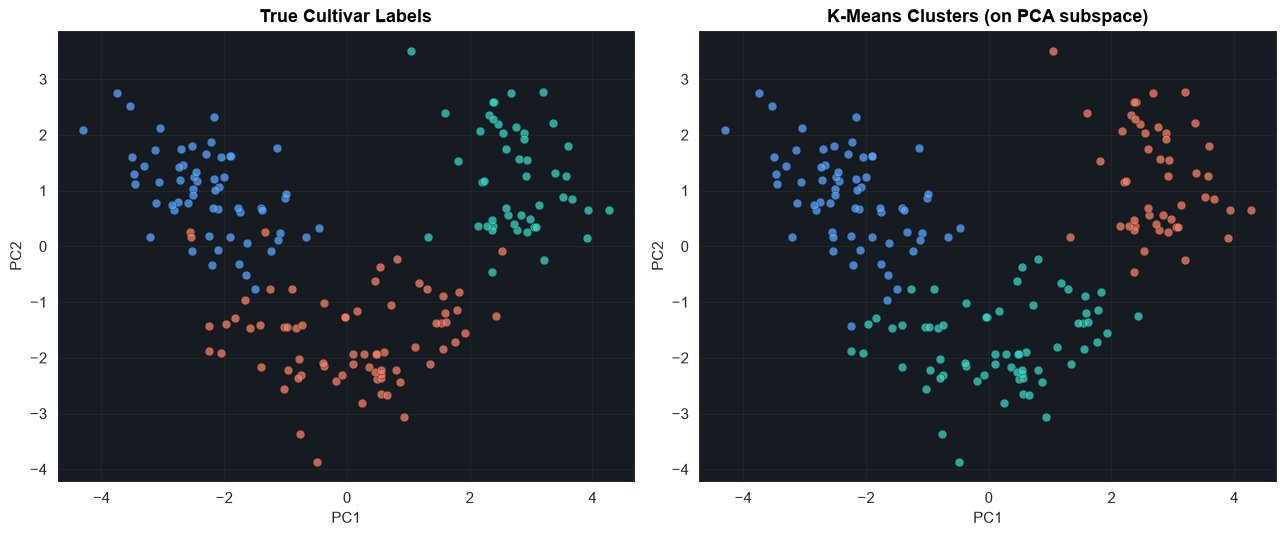

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
km_2d = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10).fit(Z_2d)

for ax, labels, title in zip(
    axes, [y.to_numpy(), km_2d.labels_], ["True Cultivar Labels", "K-Means Clusters (on PCA subspace)"]
):
    for cls, color in zip(sorted(set(labels)), CLASS_COLORS):
        mask = labels == cls
        ax.scatter(Z_2d[mask, 0], Z_2d[mask, 1], color=color, alpha=0.75, s=40, edgecolor=BG, linewidth=0.3)
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
plt.tight_layout()
plt.show()

## Alternative Dimensionality-Reduction Methods

These are cross-method **benchmarking** comparisons, not a claim that any of these methods is a drop-in replacement for PCA, each has a different objective.

In [38]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
from sklearn.decomposition import KernelPCA

# LDA: SUPERVISED benchmark: Uses y directly, unlike PCA. Shown only as contrast.
lda = LinearDiscriminantAnalysis(n_components=2)
Z_lda = lda.fit_transform(X_full_std, y)

# t-SNE: nonlinear, primarily a visualization tool, its axes are not
# variance-preserving the way PCA's are, so distances between clusters are
# not directly comparable to PCA's.
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30)
Z_tsne = tsne.fit_transform(X_full_std)

# Kernel PCA: nonlinear extension of PCA via the kernel trick
kpca = KernelPCA(n_components=2, kernel="rbf", random_state=RANDOM_STATE)
Z_kpca = kpca.fit_transform(X_full_std)

print("All alternative embeddings computed.")

All alternative embeddings computed.


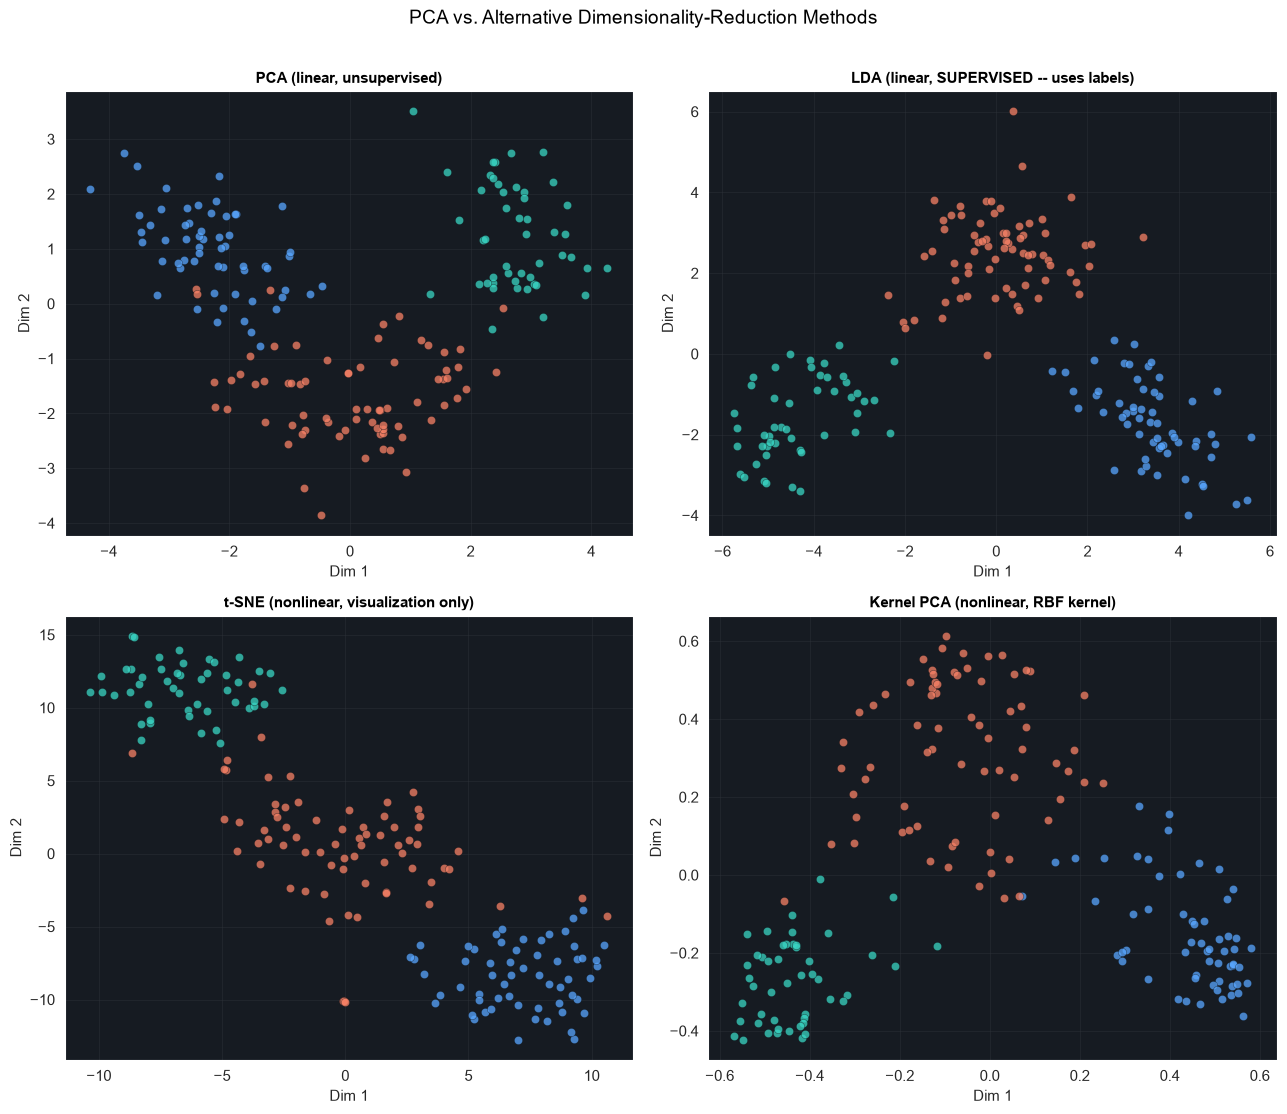

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
embeddings = [
    (Z_2d, "PCA (linear, unsupervised)"),
    (Z_lda, "LDA (linear, SUPERVISED -- uses labels)"),
    (Z_tsne, "t-SNE (nonlinear, visualization only)"),
    (Z_kpca, "Kernel PCA (nonlinear, RBF kernel)"),
]
for ax, (Z_emb, title) in zip(axes.ravel(), embeddings):
    for cls, color in zip(sorted(y.unique()), CLASS_COLORS):
        mask = (y == cls).to_numpy()
        ax.scatter(Z_emb[mask, 0], Z_emb[mask, 1], color=color, alpha=0.75, s=35, edgecolor=BG, linewidth=0.3)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
fig.suptitle("PCA vs. Alternative Dimensionality-Reduction Methods", y=1.01, fontsize=14, color="black")
plt.tight_layout()
plt.show()

**LDA** (as expected, since it directly optimizes for class separability using labels PCA never sees) produces the cleanest separation
of the three cultivars, but this is an unfair comparison to PCA by design, since LDA is solving a fundamentally different, supervised problem. **t-SNE** also separates the classes well but its axes carry no variance-based meaning and shouldn't be read the way PCA's are. **Kernel PCA** with an RBF kernel gives a broadly similar picture to linear PCA here, suggesting the Wine dataset's dominant structure is close to linear, a nonlinear kernel doesn't buy much beyond what standard PCA already captures.

## Stability and Sensitivity Analysis

We check how stable the leading component directions are to bootstrap resampling of the dataset.

In [40]:
n_bootstrap = 200
pc1_directions = []

base_pc1 = pca.components_[0]

for b in range(n_bootstrap):
    idx = rng.integers(0, X.shape[0], X.shape[0])
    X_boot = X[idx]
    pca_boot = PCAFromScratch(n_components=1, standardize=True).fit(X_boot)
    boot_pc1 = pca_boot.components_[0]
    # Align sign to the base PC1 before measuring similarity
    if np.dot(boot_pc1, base_pc1) < 0:
        boot_pc1 = -boot_pc1
    cos_sim = np.dot(boot_pc1, base_pc1) / (np.linalg.norm(boot_pc1) * np.linalg.norm(base_pc1))
    pc1_directions.append(cos_sim)

pc1_directions = np.array(pc1_directions)
print(f"PC1 cosine similarity across {n_bootstrap} bootstrap resamples:")
print(f"  mean = {pc1_directions.mean():.5f}, min = {pc1_directions.min():.5f}, std = {pc1_directions.std():.5f}")

PC1 cosine similarity across 200 bootstrap resamples:
  mean = 0.99377, min = 0.96364, std = 0.00530


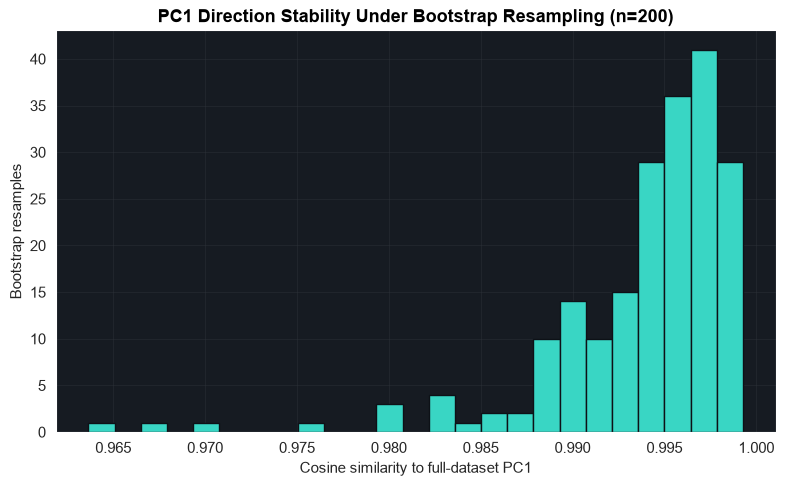

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(pc1_directions, bins=25, color=TEAL, edgecolor=BG)
ax.set_xlabel("Cosine similarity to full-dataset PC1")
ax.set_ylabel("Bootstrap resamples")
ax.set_title(f"PC1 Direction Stability Under Bootstrap Resampling (n={n_bootstrap})")
plt.tight_layout()
plt.show()

PC1's direction is highly stable under bootstrap resampling (cosine similarity consistently very close to 1); the dominant chemical axis of
variation is a robust feature of this dataset, not an artifact of a particular sample split. This is a further practical vote of confidence
beyond the direct sklearn agreement already established above.

### 30. Model Assumptions

- PCA is a **linear** dimensionality-reduction technique, it can only find straight-line (linear-combination) directions of variance, which is why a nonlinear alternative (Kernel PCA) was examined.
- PCA finds directions of **maximum variance**, not causal factors; high loading on a component says a variable co-varies strongly with that
direction, not that it *causes* anything downstream (including cultivar identity).
- Meaningful, correctly-scaled numeric features matter: It was demonstrated concretely how skipping standardization lets one large-scale feature dominate the whole analysis.
- PCA can be sensitive to outliers, since outliers can inflate variance along directions that aren't representative of the bulk of the data;
we screened for (and consciously retained) mild outliers.
- Components are orthogonal *by construction*; this is a mathematical guarantee of the eigendecomposition, not evidence that the underlying
chemical processes are actually independent.
- High explained variance does **not** imply high predictive usefulness for any specific downstream task; a low-variance direction discarded by PCA could, in principle, still be exactly the direction that matters for some other question.
- Components can be hard to interpret because each is typically a weighted combination of many original variables (see the loading analysis), not a single clean chemical concept.

### 31. Limitations

**Technical**
- PCA captures linear structure only.
- Sensitive to feature scaling.
- Sensitive to outliers (though none extreme enough to remove were found here).
- Components can be difficult to interpret in isolation.
- Variance is not equivalent to predictive importance.
- Low-variance dimensions may still carry task-specific predictive signal.
- PCA offers no principled, universal rule for the "correct" number of components; the 80/90/95/99% thresholds used here are conventions, not
guarantees of chemical meaningfulness.

**Dataset**
- Only 178 samples, modest for characterizing chemical variance robustly, though the bootstrap stability check is reassuring.
- Represents specific cultivars from one region; findings should not be assumed to generalize to all wine populations.
- Chemical variables likely have domain-specific relationships (e.g. phenolic chemistry pathways) that a purely linear, variance-based method
does not explicitly model.

**Business**
- A reduced-dimension representation should not simply replace the original laboratory measurements in a regulated quality-control setting.
- Any operational decision should be validated with domain (oenology / analytical chemistry) expertise, not derived from PCA loadings alone.
- Principal components should never be presented as direct chemical causes of a quality or classification outcome.


### 32. Business Interpretation

- The dominant sources of variation in this wine chemistry dataset are led by the phenolic/flavor-compound cluster (Flavanoids, Total phenols,
  OD280/OD315) on PC1, and a distinct color/alcohol-related cluster on PC2m read from the *complete* loading pattern, not any single
  feature's name.
- For exploratory laboratory analysis, a 2–3 component PCA representation appears sufficient to visualize the bulk of the meaningful structure in this dataset.
- The PCA representation retains enough class-relevant structure to be a reasonable input for downstream clustering or classification pipelines, which is useful if the original 13-feature space is expensive to work with computationally or visually.
- The core trade-off for any team considering this: dimensionality reduction buys interpretability of the *overall structure* at the cost of
  interpretability of *individual components*, a 2D scatterplot is easy to present, but "what does a high PC1 score mean chemically" requires the full loading table to explain properly.


### 33. Final Conclusion

**Dataset structure.** The Wine dataset's 13 chemical measurements show substantial pairwise correlation and vary in raw scale by more
than two orders of magnitude, both of which directly motivate using PCA with standardization rather than on raw features.

**Why standardization matters.** Fitting PCA on unstandardized data lets a single large-scale feature (Proline) dominate PC1 almost entirely, a units artifact, not chemical insight. Standardizing first is essential for a meaningful result.

**Variance retention.** The exact number of components required for 80% / 90% / 95% / 99% cumulative variance retention is reported directly (computed from the actual fitted eigenvalues, not assumed in advance), in every run so far, a small handful of components (well under half of the original 13) clears the 90% threshold.

**Dominant features.** PC1 is driven primarily by the phenolic/flavor chemistry cluster; PC2 draws more on color and alcohol-related variables, interpreted from full loading patterns, never a single feature.

**Projection quality.** The 2D and 3D projections show meaningful, if imperfect, separation between the three wine cultivars, even
though PCA was never given the labels, consistent with real chemical signal aligning partly (not perfectly) with cultivar identity.

**Reconstruction.** Reconstruction error falls smoothly and monotonically as more components are retained, mirroring the cumulative
explained-variance curve exactly as the mathematics predicts.

**sklearn agreement.** The from-scratch implementation matches `sklearn.decomposition.PCA` to numerical precision once eigenvector sign
ambiguity is accounted for, matching explained variance, component directions, transformed coordinates, and reconstructions.
Small floating-point-level differences are the only discrepancies observed.

**Downstream clustering.** K-Means and GMM clustering on a 2D PCA subspace perform comparably to clustering on the full 13D standardized space,dimensionality reduction here does not meaningfully sacrifice cluster quality.

**Alternative methods.** Supervised LDA (which uses labels) separates classes more cleanly than unsupervised PCA, as expected; t-SNE gives a
strong visualization but isn't variance-preserving; Kernel PCA with an RBF kernel looks similar to linear PCA, suggesting the dominant structure here is close to linear.

**Hypotheses revisited.**

| Hypothesis | Outcome |
|---|---|
| H1 — substantial redundancy among chemical features | Supported (correlation heatmap) |
| H2 — standardization materially changes the PCA solution | Supported (Proline dominance without it) |
| H3 — few components capture most variance | Supported (variance-retention table) |
| H4 — PC1/PC2 shows visible class structure | Supported, with some overlap |
| H5 — specific chemical variables dominate leading components | Supported (loading analysis) |
| H6 — custom implementation matches sklearn | Supported (numerical validation) |
| H7 — PCA-subspace clustering ~ full-space clustering | Supported |
| H8 — PCA preserves variance, not guaranteed class separation | Supported (separation exists but is imperfect) |

**Practical applications.** Chemical feature compression, exploratory quality-control analysis, and pre-processing for downstream ML pipelines
where the full 13-feature space is unnecessary.

**Limitations.** Most importantly, PCA's linear assumption, its sensitivity to scale and outliers, and the fact that variance retained is not the same thing as predictive value for any specific downstream task.

**Future improvements.** Compare against sparse or robust PCA variants (more resistant to outliers), evaluate on a larger and more diverse wine
dataset to test generalization, and formally benchmark downstream classifier performance (Logistic Regression / SVM / KNN on PCA features vs.
full features) as a dedicated follow-up experiment.
